# 🏆 Le Champion Optuna (Standalone Model)

Ce notebook implémente la configuration exacte trouvée par l'optimisation bayésienne.
C'est un **Modèle Unique** (pas d'ensemble, pas de règles manuelles), purement optimisé sur la donnée.

**Caractéristiques Clés :**
*   **Simplicité** : Profondeur max de 3 (très faible) pour éviter l'overfitting.
*   **Lenteur** : Learning Rate très bas (0.014) avec beaucoup d'arbres (644).
*   **Features** : Frequency Encoding pour la Source, Pages/Age, et Is_Active.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

## 1. Préparation des Données & Feature Engineering Spécifique
On applique exactement les transformations validées par Optuna.

In [2]:
print("📥 Chargement des données...")
train_df = pd.read_csv('conversion_data_train.csv')
test_df = pd.read_csv('conversion_data_test.csv')
target = train_df['converted']
train_df = train_df.drop('converted', axis=1)

# Concaténation pour encoding cohérent
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# --- Feature Engineering (Optuna Selection) ---
def apply_optuna_features(df):
    df = df.copy()
    # 1. Pages Per Age (Validé)
    df['pages_per_age'] = df['total_pages_visited'] / (df['age'] + 0.1)
    
    # 2. Is Active (Validé)
    df['is_active'] = (df['total_pages_visited'] > 2).astype(int)
    
    # 3. Source Frequency Encoding (Validé - NOUVEAU)
    # On calcule les fréquences sur tout le dataset pour robustesse
    freq = df['source'].value_counts(normalize=True)
    df['source_freq'] = df['source'].map(freq)
    
    # Interaction (Rejeté par Optuna -> On ne met PAS)
    # df['interaction'] ... 

    return df

full_df = apply_optuna_features(full_df)

# Encoding Classique pour Country (LabelEncoder suffisant pour Trees)
le = LabelEncoder()
full_df['country'] = le.fit_transform(full_df['country'])

# Drop original 'source' car remplacée par 'source_freq'
# (Optuna a utilisé frequency encoding, donc on remplace la feature catégorielle brute)
full_df = full_df.drop('source', axis=1)

# Split Train/Test
X = full_df.iloc[:len(train_df)]
X_test = full_df.iloc[len(train_df):]
y = target

print(f"✅ Features prêtes. Colonnes : {list(X.columns)}")

📥 Chargement des données...
✅ Features prêtes. Colonnes : ['country', 'age', 'new_user', 'total_pages_visited', 'pages_per_age', 'is_active', 'source_freq']


## 2. Configuration du Champion
Paramètres exacts issus du Trial #27 (Best).

In [3]:
optuna_params = {
    'learning_rate': 0.01436,
    'max_iter': 644,
    'max_depth': 3,          # Le secret ! (Anti-overfitting)
    'min_samples_leaf': 69,
    'l2_regularization': 0.0592,
    'loss': 'log_loss',
    'random_state': 42,
    'categorical_features': [0] # Seul 'country' (index 0) est catégoriel pur maintenant. source est numérique (freq).
}

model = HistGradientBoostingClassifier(**optuna_params)

## 3. Validation Robuste (10-Fold CV)

In [4]:
print("⚔️ Lancement de la Cross-Validation (10 Folds)...")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['f1', 'recall', 'precision', 'roc_auc']
scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

print("\n📊 RÉSULTATS MOYENS (10 Folds) :")
print(f"   🎯 F1 Score  : {scores['test_f1'].mean():.5f}  (+/- {scores['test_f1'].std():.4f})")
print(f"   🔄 Recall    : {scores['test_recall'].mean():.5f}")
print(f"   🎯 Precision : {scores['test_precision'].mean():.5f}")
print(f"   📈 ROC AUC   : {scores['test_roc_auc'].mean():.5f}")

⚔️ Lancement de la Cross-Validation (10 Folds)...

📊 RÉSULTATS MOYENS (10 Folds) :
   🎯 F1 Score  : 0.76464  (+/- 0.0124)
   🔄 Recall    : 0.69466
   🎯 Precision : 0.85043
   📈 ROC AUC   : 0.98573


## 4. Visualisation des Métriques par Fold

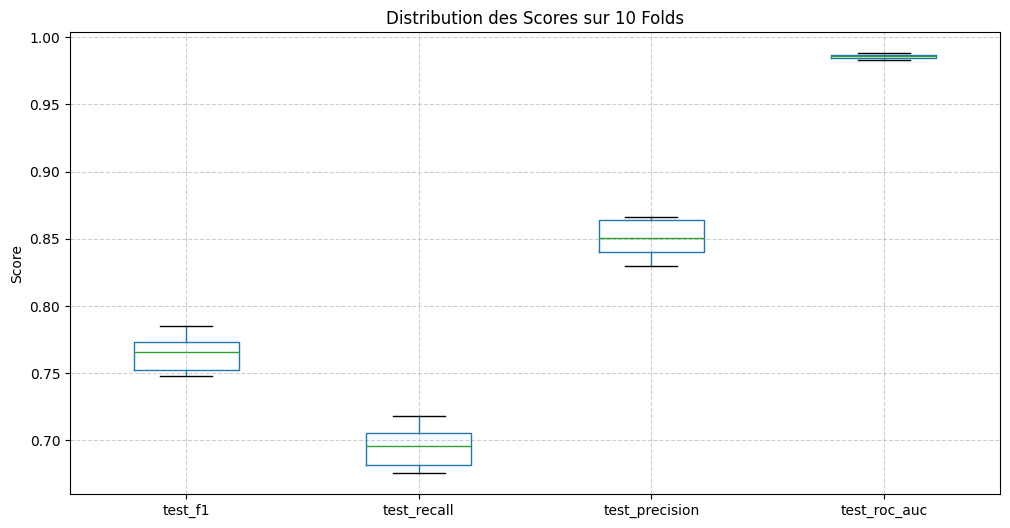

In [5]:
metrics_df = pd.DataFrame(scores)
metrics_cols = ['test_f1', 'test_recall', 'test_precision', 'test_roc_auc']

plt.figure(figsize=(12, 6))
metrics_df[metrics_cols].boxplot()
plt.title('Distribution des Scores sur 10 Folds')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Entraînement Final & Soumission
On entraîne le modèle sur 100% des données et on génère le fichier.

In [6]:
print("🚀 Entraînement Final sur tout le Dataset...")
model.fit(X, y)
y_pred = model.predict(X_test)

filename = 'submission_OPTUNA_CHAMPION.csv'
pd.DataFrame({'converted': y_pred}).to_csv(filename, index=False)

print(f"✅ Fichier de soumission généré : {filename}")
print(f"   Nombre de conversions prédites : {y_pred.sum()}")

🚀 Entraînement Final sur tout le Dataset...
✅ Fichier de soumission généré : submission_OPTUNA_CHAMPION.csv
   Nombre de conversions prédites : 833
